# ex016_Xie2015_B3

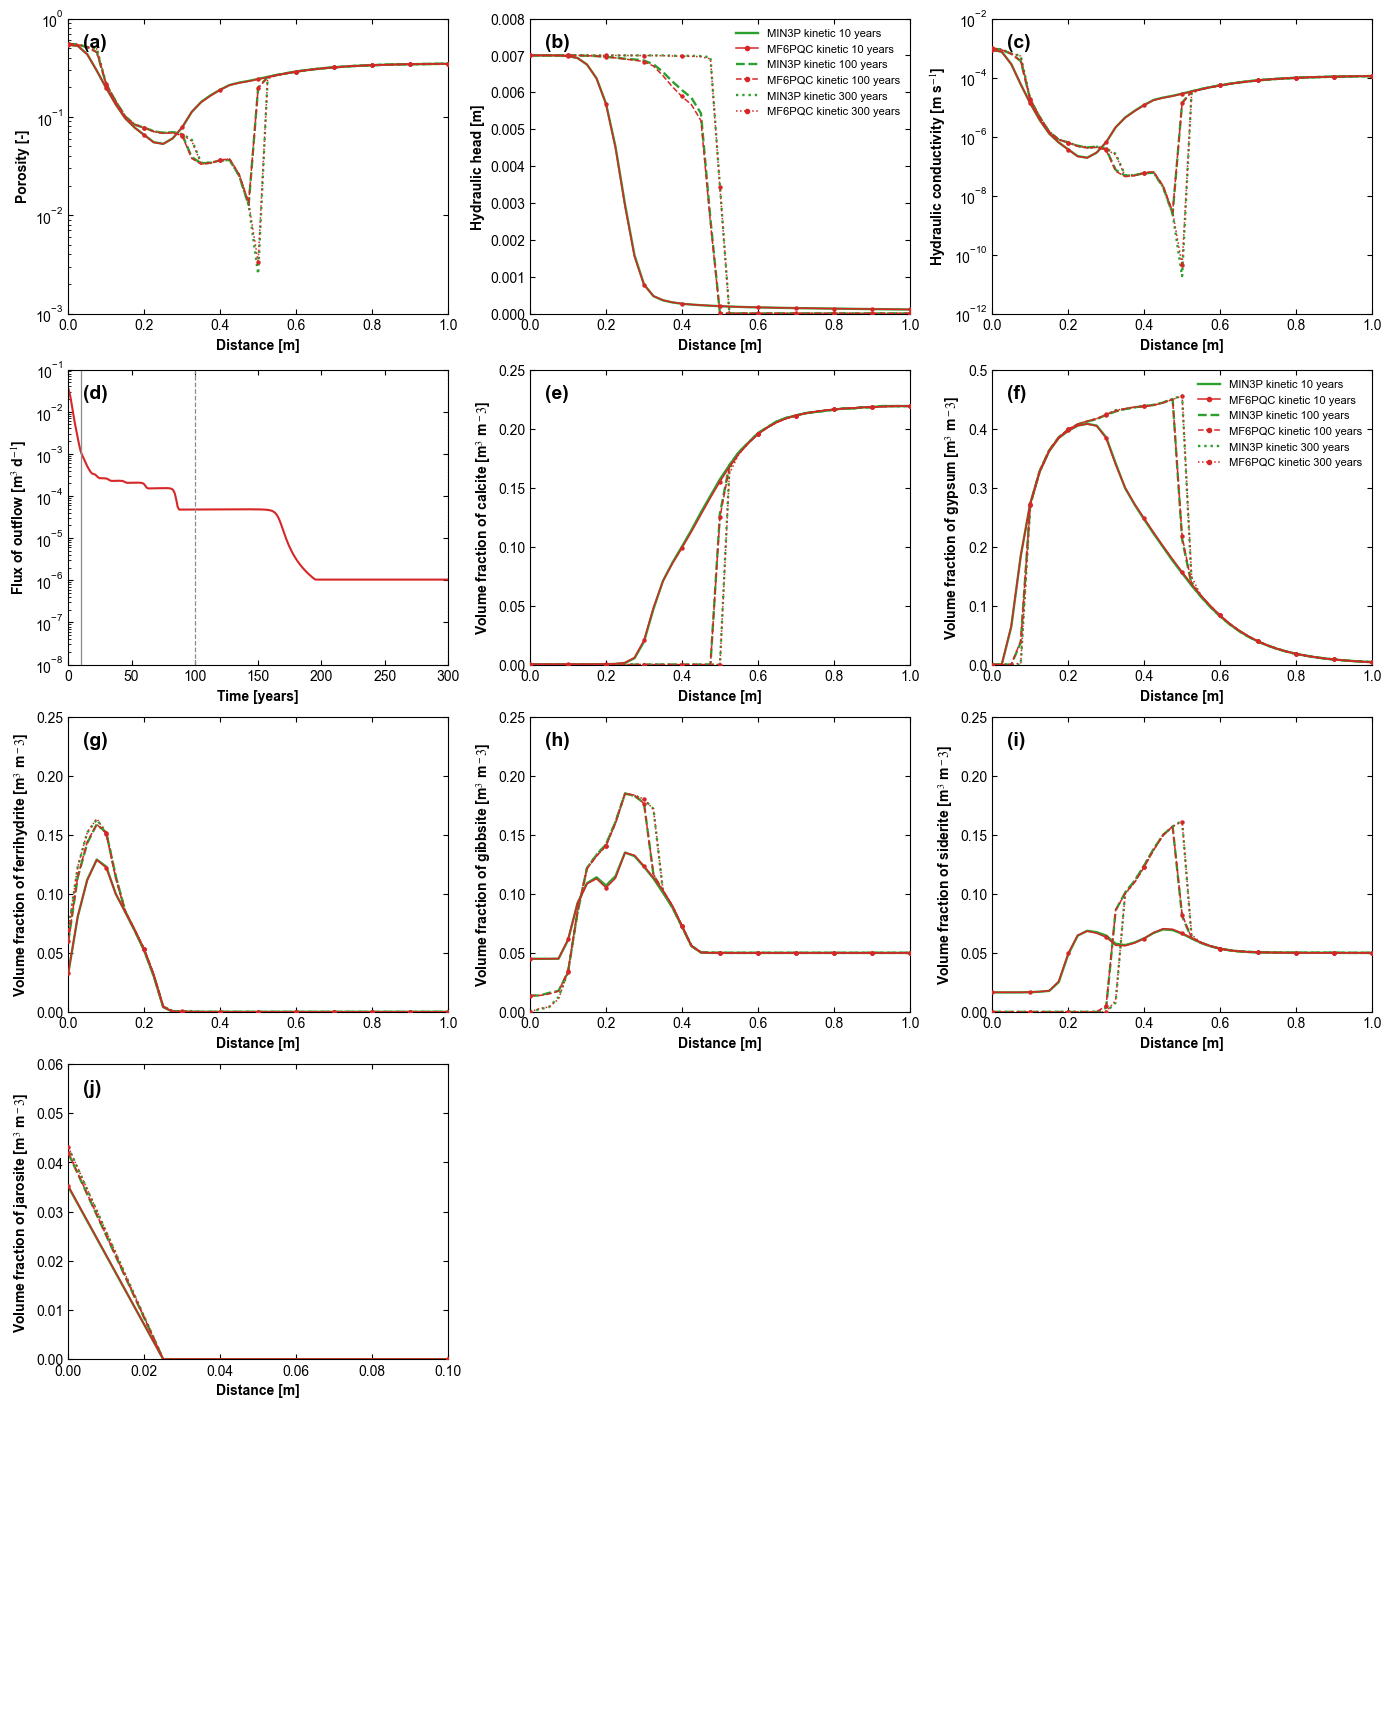

In [1]:
from run import MINERAL_MOLAR_VOLUMES

import pandas as pd
from IPython.display import display

comparison_rows = []
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CASE_DIR = Path.cwd()
INPUT_DIR = CASE_DIR / "input_data"
OUTPUT_DIR = CASE_DIR / "output"
SIMULATION_DIR = CASE_DIR / "simulation"
import flopy
from matplotlib.lines import Line2D

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 10,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "mathtext.fontset": "stix",
    }
)
LENGTH = 2.0
SECONDS_PER_DAY = 86400.0
head_path = SIMULATION_DIR / "gwf_model.hds"
results = np.load(OUTPUT_DIR / "results.npy")
headings = (OUTPUT_DIR / "results_headings.txt").read_text(encoding="utf-8-sig").splitlines()
result_times = np.load(OUTPUT_DIR / "results_times.npy")
porosity = np.load(OUTPUT_DIR / "results_porosity.npy")
permeability = np.load(OUTPUT_DIR / "results_K.npy")
reference_hydro = pd.read_csv(INPUT_DIR / "MIN3P_hydro.csv")
reference_minerals = pd.read_csv(INPUT_DIR / "MIN3P_minerals.csv")
sim = flopy.mf6.MFSimulation.load(sim_ws=str(SIMULATION_DIR), sim_name="model", verbosity_level=0)
gwf = sim.get_model("gwf_model")
delr = gwf.dis.delr.array.ravel()
x_mf6 = np.cumsum(delr) - 0.5 * delr
x_min3p = np.linspace(0.0, LENGTH, len(reference_hydro))
years = result_times / 365.0


def state_index(year):
    index = int(np.abs(years - year).argmin())
    return index


def mineral_profile(year, mineral):
    return results[state_index(year), headings.index(mineral)] * MINERAL_MOLAR_VOLUMES[mineral]


head_file = flopy.utils.HeadFile(str(head_path))
head_times = np.asarray(head_file.get_times()) / 365.0
head_kstpkper = head_file.get_kstpkper()


def head_profile(year):
    index = int(np.abs(head_times - year).argmin())
    return head_file.get_data(kstpkper=head_kstpkper[index])[0, 0]


styles = {10: "-", 100: "--", 300: ":"}


def resample(values):
    return np.interp(x_min3p, x_mf6, np.asarray(values))


fig, combined_axes = plt.subplots(5, 3, figsize=(13.8, 17.0), constrained_layout=True)
axes = np.array(combined_axes.flat[:4]).reshape(2, 2)
panels = [
    (
        axes[0, 0],
        "Porosity",
        lambda year: porosity[state_index(year)],
        "Porosity [-]",
        (0.001, 1.0),
        True,
    ),
    (axes[0, 1], "Hydraulic head", head_profile, "Hydraulic head [m]", (0.0, 0.008), False),
    (
        axes[1, 0],
        "Hydraulic conductivity",
        lambda year: permeability[state_index(year)] / SECONDS_PER_DAY,
        "Hydraulic conductivity [m s$^{-1}$]",
        (1e-12, 0.01),
        True,
    ),
]
for ax, key, getter, ylabel, ylim, log_scale in panels:
    for year, style in styles.items():
        error = resample(getter(year)) - reference_hydro[f"{key} {year}years"]
        comparison_rows.append(
            {
                "Variable": key,
                "Time (yr)": year,
                "RMSE": np.sqrt(np.mean(error**2)),
                "Max abs": np.max(np.abs(error)),
            }
        )
        ax.plot(x_min3p, reference_hydro[f"{key} {year}years"], color="tab:green", ls=style, lw=1.7)
        ax.plot(
            x_min3p,
            resample(getter(year)),
            color="tab:red",
            ls=style,
            lw=1.1,
            marker="o",
            ms=2.2,
            markevery=4,
            zorder=3,
        )
    ax.set(xlim=(0, 1.0), ylim=ylim, xlabel="Distance [m]", ylabel=ylabel)
    if log_scale:
        ax.set_yscale("log")
right_ghb = gwf.get_package("ghb_right")
right_bhead = float(right_ghb.stress_period_data.get_data(key=0)["bhead"][0])
right_distance = 0.5 * delr[-1]
right_heads = np.empty_like(years)
right_heads[0] = 0.0
right_heads[1:] = [head_profile(year)[-1] for year in years[1:]]
outflow = permeability[:, -1] * (right_heads - right_bhead) / right_distance
outflow[0] = permeability[0, -1] * 0.007 / LENGTH
ax = axes[1, 1]
ax.plot(years, np.maximum(outflow, 1e-12), color="tab:red", lw=1.5)
for year, style in styles.items():
    ax.axvline(year, color="0.55", ls=style, lw=0.9)
ax.set(
    xlim=(0, 300),
    ylim=(1e-08, 0.1),
    xlabel="Time [years]",
    ylabel="Flux of outflow [m$^3$ d$^{-1}$]",
)
ax.set_yscale("log")
for ax, label in zip(axes.flat, ("(a)", "(b)", "(c)", "(d)"), strict=False):
    ax.text(0.04, 0.95, label, transform=ax.transAxes, va="top", fontsize=14, fontweight="bold")
    ax.tick_params(top=True, right=True)
    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")
legend = [
    item
    for year, style in styles.items()
    for item in (
        Line2D([], [], color="tab:green", ls=style, lw=1.7, label=f"MIN3P kinetic {year} years"),
        Line2D(
            [],
            [],
            color="tab:red",
            ls=style,
            marker="o",
            lw=1.1,
            ms=3,
            label=f"MF6PQC kinetic {year} years",
        ),
    )
]
axes[0, 1].legend(handles=legend, frameon=False, fontsize=8, loc="upper right")
mineral_panels = [
    ("Calcite", (0.0, 0.25), (0.0, 1.0)),
    ("Gypsum", (0.0, 0.5), (0.0, 1.0)),
    ("Ferrihydrite", (0.0, 0.25), (0.0, 1.0)),
    ("Gibbsite", (0.0, 0.25), (0.0, 1.0)),
    ("Siderite", (0.0, 0.25), (0.0, 1.0)),
    ("Jarosite", (0.0, 0.06), (0.0, 0.1)),
]
axes = np.array(combined_axes.flat[4:10]).reshape(3, 2)
for ax, (mineral, ylim, xlim), label in zip(
    axes.flat, mineral_panels, ("(e)", "(f)", "(g)", "(h)", "(i)", "(j)"), strict=False
):
    for year, style in styles.items():
        error = (
            resample(mineral_profile(year, mineral)) - reference_minerals[f"{mineral} {year}years"]
        )
        comparison_rows.append(
            {
                "Variable": mineral,
                "Time (yr)": year,
                "RMSE": np.sqrt(np.mean(error**2)),
                "Max abs": np.max(np.abs(error)),
            }
        )
        ax.plot(
            x_min3p,
            reference_minerals[f"{mineral} {year}years"],
            color="tab:green",
            ls=style,
            lw=1.7,
        )
        ax.plot(
            x_min3p,
            resample(mineral_profile(year, mineral)),
            color="tab:red",
            ls=style,
            lw=1.1,
            marker="o",
            ms=2.2,
            markevery=4,
            zorder=3,
        )
    ax.set(
        xlim=xlim,
        ylim=ylim,
        xlabel="Distance [m]",
        ylabel=f"Volume fraction of {mineral.lower()} [m$^3$ m$^{-3}$]",
    )
    ax.text(0.04, 0.95, label, transform=ax.transAxes, va="top", fontsize=14, fontweight="bold")
    ax.tick_params(top=True, right=True)
    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")
axes[0, 1].legend(handles=legend, frameon=False, fontsize=8, loc="upper right")
for ax in combined_axes.flat[10:]:
    ax.set_axis_off()
fig.savefig(OUTPUT_DIR / "comparison.png", dpi=180, bbox_inches="tight")
plt.show()
comparison = pd.DataFrame(comparison_rows)
comparison = comparison.pivot(
    index="Variable", columns="Time (yr)", values=["RMSE", "Max abs"]
).reindex(comparison["Variable"].drop_duplicates())
display(
    comparison.style.format("{:.6g}").format_index("{:.6g}", axis=1, level=1).set_uuid("ex016_1")
)

c:\ProgramFiles\Miniconda\envs\work\Lib\site-packages\matplotlib_inline\config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


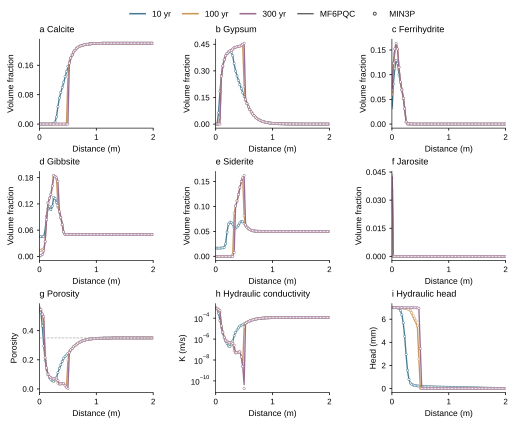

In [2]:
%config InlineBackend.figure_format = 'svg'
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

W = 183 / 25.4
COL = ["#477B92", "#C99659", "#986D91"]
mpl.rcdefaults()
mpl.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 9,
        "axes.titlesize": 9,
        "axes.labelsize": 8.5,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8.5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.linewidth": 0.65,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "savefig.facecolor": "white",
    }
)
raw = np.load(OUTPUT_DIR / "results.npy")
headings = (OUTPUT_DIR / "results_headings.txt").read_text(encoding="utf-8-sig").splitlines()
result_times = np.load(OUTPUT_DIR / "results_times.npy")
profile_times = [10, 100, 300]
mineral_order = ["Calcite", "Gypsum", "Ferrihydrite", "Gibbsite", "Siderite", "Jarosite"]
D = {
    "reference_x_m": np.linspace(0, 2, len(reference_hydro)),
    "reference_mineral_x_m": np.linspace(0, 2, len(reference_minerals)),
    "reference_minerals": np.array(
        [
            [reference_minerals[f"{m} {t}years"].to_numpy() for m in mineral_order]
            for t in profile_times
        ]
    ),
}
for key, column in [
    ("reference_phi", "Porosity"),
    ("reference_K_m_s", "Hydraulic conductivity"),
    ("reference_head_m", "Hydraulic head"),
]:
    D[key] = np.array([reference_hydro[f"{column} {t}years"].to_numpy() for t in profile_times])
model = flopy.mf6.MFSimulation.load(sim_ws=str(SIMULATION_DIR), verbosity_level=0)
dx = model.get_model("gwf_model").dis.delr.array.ravel()
D["x_m"] = np.cumsum(dx) - dx / 2
D["phi"] = np.load(OUTPUT_DIR / "results_porosity.npy")
D["K_m_d"] = np.load(OUTPUT_DIR / "results_K.npy")
D["time_yr"] = result_times / 365.0
D["mineral_names"] = np.array(
    ["Calcite", "Gypsum", "Ferrihydrite", "Gibbsite", "Siderite", "Jarosite"]
)
D["molar_volumes_L_mol"] = np.array([MINERAL_MOLAR_VOLUMES[name] for name in D["mineral_names"]])
D["minerals"] = np.stack(
    [
        raw[:, headings.index(n)] * v
        for n, v in zip(D["mineral_names"], D["molar_volumes_L_mol"], strict=False)
    ],
    axis=1,
)
D["selected_yr"] = np.array([10, 100, 300])
with flopy.utils.HeadFile(SIMULATION_DIR / "gwf_model.hds", precision="double") as hf:
    available = np.asarray(hf.get_times())
    D["head_m"] = np.stack(
        [
            hf.get_data(totim=float(available[np.argmin(abs(available - year * 365))])).ravel()
            for year in D["time_yr"]
        ]
    )


def _manuscript_layout_08(fig):
    fig.canvas.draw()
    width_pt, height_pt = fig.get_size_inches() * 72
    offsets = [
        (0, 0),
        (0, 0),
        (0, 0),
        (0, -17.195076),
        (0, -17.195076),
        (0, -17.195076),
        (0, -34.5),
        (0, -34.5),
        (0, -34.5),
    ]
    for ax, (dx, dy) in zip(fig.axes, offsets, strict=True):
        pos = ax.get_position()
        ax.set_position([pos.x0 + dx / width_pt, pos.y0 - dy / height_pt, pos.width, pos.height])
    for legend in fig.legends:
        box = legend.get_bbox_to_anchor().transformed(fig.transFigure.inverted())
        legend.set_bbox_to_anchor(
            (box.x0 + 0 / width_pt, box.y0 - 6 / height_pt, box.width, box.height),
            transform=fig.transFigure,
        )


def save(n, fig, axes):
    _manuscript_layout_08(fig)
    fig.savefig(OUTPUT_DIR / "comparison_paper.png", dpi=180, bbox_inches="tight")
    plt.show()


def title(ax, letter, name):
    ax.set_title(f"{letter}  {name}", loc="left", pad=7, fontsize=9)


def grid(rows, cols, height, top=0.86, bottom=0.1, wspace=0.5, hspace=0.67):
    fig, axs = plt.subplots(rows, cols, figsize=(W, height), squeeze=False)
    fig.subplots_adjust(left=0.08, right=0.98, top=top, bottom=bottom, wspace=wspace, hspace=hspace)
    return (fig, list(axs.flat))


def legend(fig, times, unit="yr", ref="MIN3P", colors=None):
    colors = colors or (COL if len(times) == 3 else [COL[0], COL[-1]])
    handles = [
        Line2D([], [], color=c, lw=1.5, label=f"{t:,} {unit}")
        for t, c in zip(times, colors, strict=False)
    ]
    handles += [
        Line2D([], [], color=".3", lw=1.2, label="MF6PQC"),
        Line2D([], [], color=".3", ls="none", marker="o", mfc="white", ms=3, label=ref),
    ]
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.53, 0.991),
        ncol=len(handles),
        columnspacing=1.4,
        handlelength=1.8,
    )


def curves(ax, d, key, refkey, component=None, scale=1, refscale=1, interior=False, xmax=2):
    colors = COL if len(d["selected_yr"]) == 3 else [COL[0], COL[-1]]
    for j, (t, c) in enumerate(zip(d["selected_yr"], colors, strict=False)):
        idx = np.flatnonzero(np.isclose(d["time_yr"], t)).item()
        y = d[key][idx] if component is None else d[key][idx, component]
        cells = slice(1, -1) if interior else slice(None)
        ax.plot(d["x_m"][cells], y[cells] * scale, color=c, lw=1.35)
        rx = d["reference_mineral_x_m"] if refkey == "reference_minerals" else d["reference_x_m"]
        ry = d[refkey][j] if component is None else d[refkey][j, component]
        ax.plot(rx, ry * refscale, ls="none", marker="o", ms=2.3, mfc="white", mec=c, mew=0.5)
    ax.set(
        xlim=(0, xmax), xlabel="Distance (m)", xticks=[0, 0.4, 0.8] if xmax == 0.8 else [0, 1, 2]
    )
    ax.yaxis.set_major_locator(MaxNLocator(4))


def fig8():
    d = D
    fig, axs = grid(3, 3, 6.6, top=0.902, bottom=0.084, wspace=0.55, hspace=0.68)
    legend(fig, [10, 100, 300])
    for i, name in enumerate(d["mineral_names"]):
        curves(axs[i], d, "minerals", "reference_minerals", component=i)
        title(axs[i], chr(97 + i), str(name))
        axs[i].set_ylabel("Volume fraction", labelpad=3)
    curves(axs[6], d, "phi", "reference_phi")
    title(axs[6], "g", "Porosity")
    axs[6].set_ylabel("Porosity")
    axs[6].axhline(0.35, color=".65", ls="--", lw=0.7)
    curves(axs[7], d, "K_m_d", "reference_K_m_s", scale=1 / 86400)
    title(axs[7], "h", "Hydraulic conductivity")
    axs[7].set_ylabel("K (m/s)")
    axs[7].set_yscale("log")
    curves(axs[8], d, "head_m", "reference_head_m", scale=1000, refscale=1000)
    title(axs[8], "i", "Hydraulic head")
    axs[8].set_ylabel("Head (mm)")
    save(8, fig, axs)


fig8()